In [4]:
#Build correlation matrix for each mouse in TST and OFT, and save the correlation matrix as csv file. Also plot the clustermap of the correlation matrix.

In [5]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from statsmodels.formula.api import mixedlm
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import warnings

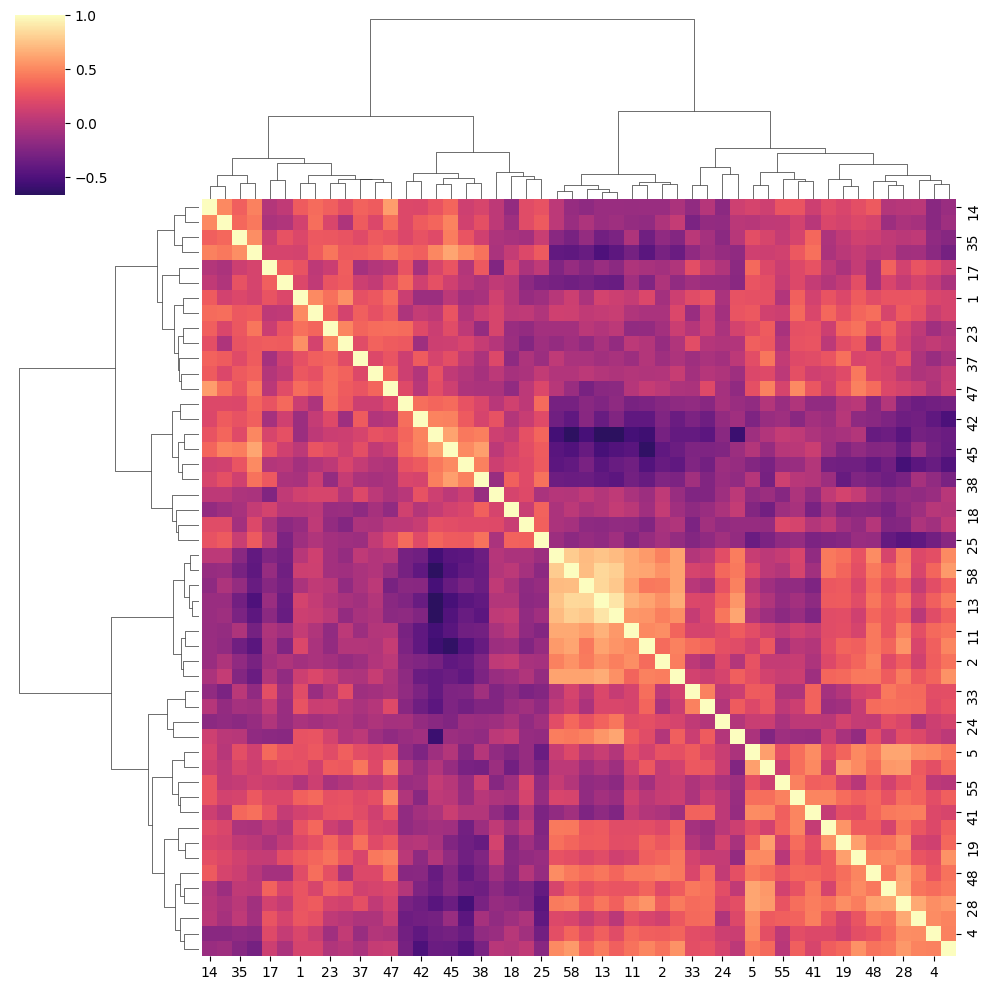

In [6]:
project_path = r'G:\XJN_M2project'
test = 'test3'
signal_data_path = os.path.join(project_path,'signal_data',test)
for condition in ['rescue']:
    condition_path = os.path.join(signal_data_path,condition)
    miceIDs = [f for f in os.listdir(condition_path) if os.path.isdir(os.path.join(condition_path, f))]
    miceIDs = ['5806']
    for miceID in miceIDs:
            if miceID == 'group':
                continue
            data = pd.read_csv(os.path.join(project_path,'signal_data',test,condition,miceID,'signal_save',f'{miceID}_{condition}_all_cell_table_TST.csv'),index_col=0)
            corr_matrix =np.corrcoef(data.T)
            corr_matrix = pd.DataFrame(corr_matrix,index=data.columns,columns=data.columns)
            save_dir = os.path.join(project_path,'correlation_analysis',test,condition,miceID)
            if not os.path.exists(save_dir):os.makedirs(save_dir)
            corr_matrix.to_csv(os.path.join(save_dir,f'correlation_TST.csv'))
            sns.clustermap(corr_matrix,method='ward',metric='euclidean', cmap='magma',center = 0)
            plt.savefig(os.path.join(project_path,'correlation_analysis',test,condition,miceID, f'{miceID}_{condition}_all_cell_TST_corr_clustermap.pdf'),dpi=300)
            plt.show()
            plt.close()

